In [66]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline

In [50]:
IMG_SIZE = 256
BATCH_SIZE = 32

In [51]:
data = tf.keras.preprocessing.image_dataset_from_directory(
    "Dataset without augmentation",
    shuffle = True,
    image_size = (IMG_SIZE, IMG_SIZE),
    batch_size = BATCH_SIZE
)

Found 55448 files belonging to 39 classes.


In [52]:
classes = data.class_names
classes

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Background_without_leaves',
 'Blueberry___healthy',
 'Cherry___Powdery_mildew',
 'Cherry___healthy',
 'Corn___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn___Common_rust',
 'Corn___Northern_Leaf_Blight',
 'Corn___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot'

In [53]:
len(data)

1733

In [54]:
for img_batch, label_batch in data.take(1):
    print(img_batch.shape)
    print(label_batch.numpy())

(32, 256, 256, 3)
[ 5 30 20 36 29 25 14  6 27 21 16  3 17 36 33 16  7 16 13 34 36 34  5 16
 25 36 22  9 26 36  5 21]


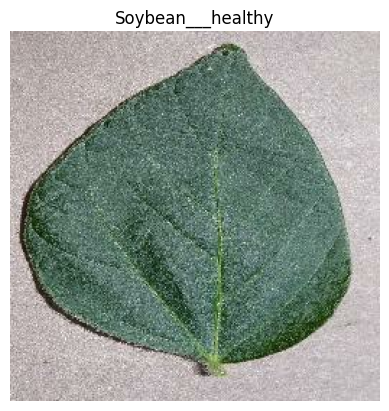

In [55]:
for img_batch, label_batch in data.take(1):
    plt.imshow(img_batch[0].numpy().astype(int))
    plt.title(classes[label_batch[0]])
    plt.axis('off')

In [56]:
len(data)

1733

In [57]:
train_size = 0.8
validation_size = 0.1
test_size = 0.1

In [58]:
len(data)*train_size

1386.4

In [59]:
train_data = data.take(1386)
len(train_data)

1386

In [60]:
test_data = data.skip(1386)
len(test_data)

347

In [61]:
len(data)*validation_size

173.3

In [62]:
validation_data = test_data.take(173)
len(validation_data)

173

In [63]:
test_data = test_data.skip(173)
len(test_data)

174

In [64]:
train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
validation_data = validation_data.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_data = test_data.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [67]:
preprocess_images = tf.keras.Sequential(
    [
        tf.keras.layers.Resizing(IMG_SIZE, IMG_SIZE),
        tf.keras.layers.Rescaling(1./255)
    ]
)